# IAC Cloud Data Visualization

This notebook visualizes the IAC cloud event data and the extracted linear extensions.


In [ ]:
import sys
import os
import importlib.util

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Direct import to avoid package init issues
module_path = os.path.join('..', 'src', 'utils', 'iac_cloud_data_processing.py')
spec = importlib.util.spec_from_file_location('iac_proc', module_path)
iac_proc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(iac_proc)

# Extract functions
load_iac_cloud_data = iac_proc.load_iac_cloud_data
create_combined_node = iac_proc.create_combined_node
extract_linear_extensions_by_session = iac_proc.extract_linear_extensions_by_session
extract_linear_extensions_deduplicated = iac_proc.extract_linear_extensions_deduplicated
get_unique_nodes = iac_proc.get_unique_nodes
convert_to_ranking_indices = iac_proc.convert_to_ranking_indices
get_session_statistics = iac_proc.get_session_statistics

print("✅ All modules loaded successfully!")


✅ All modules loaded successfully!


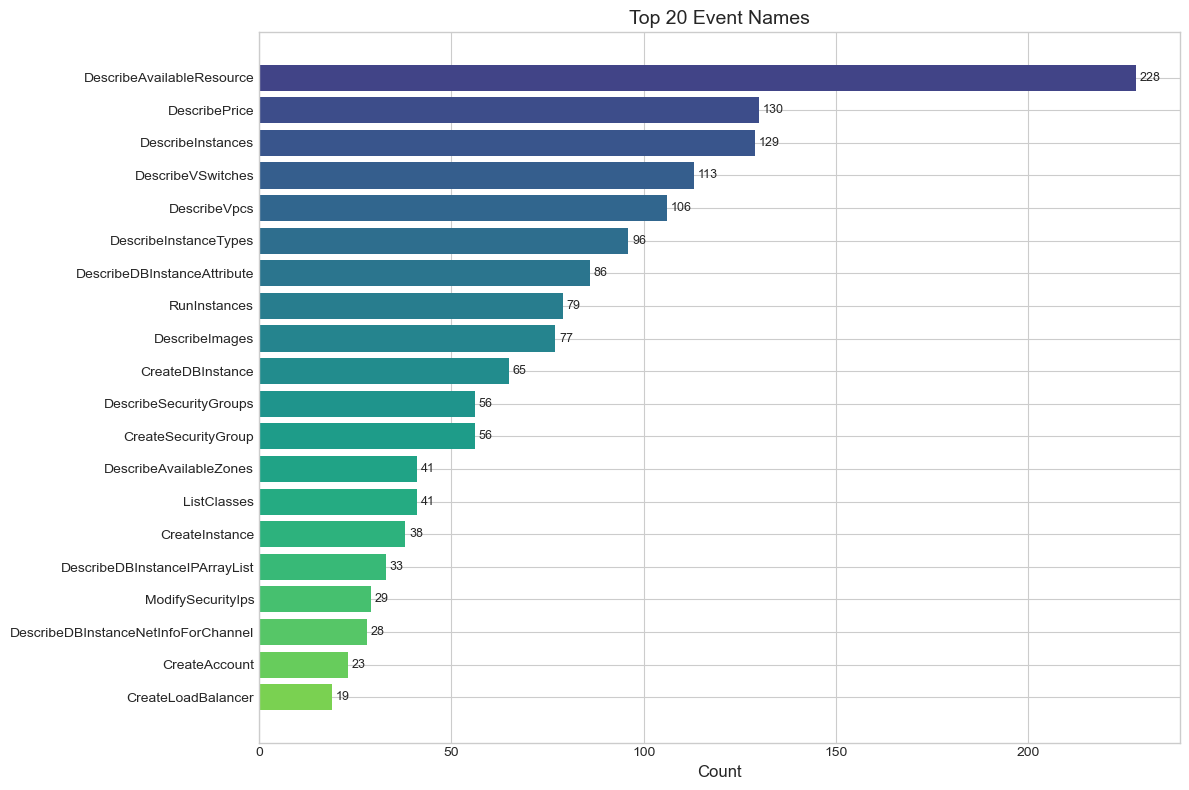

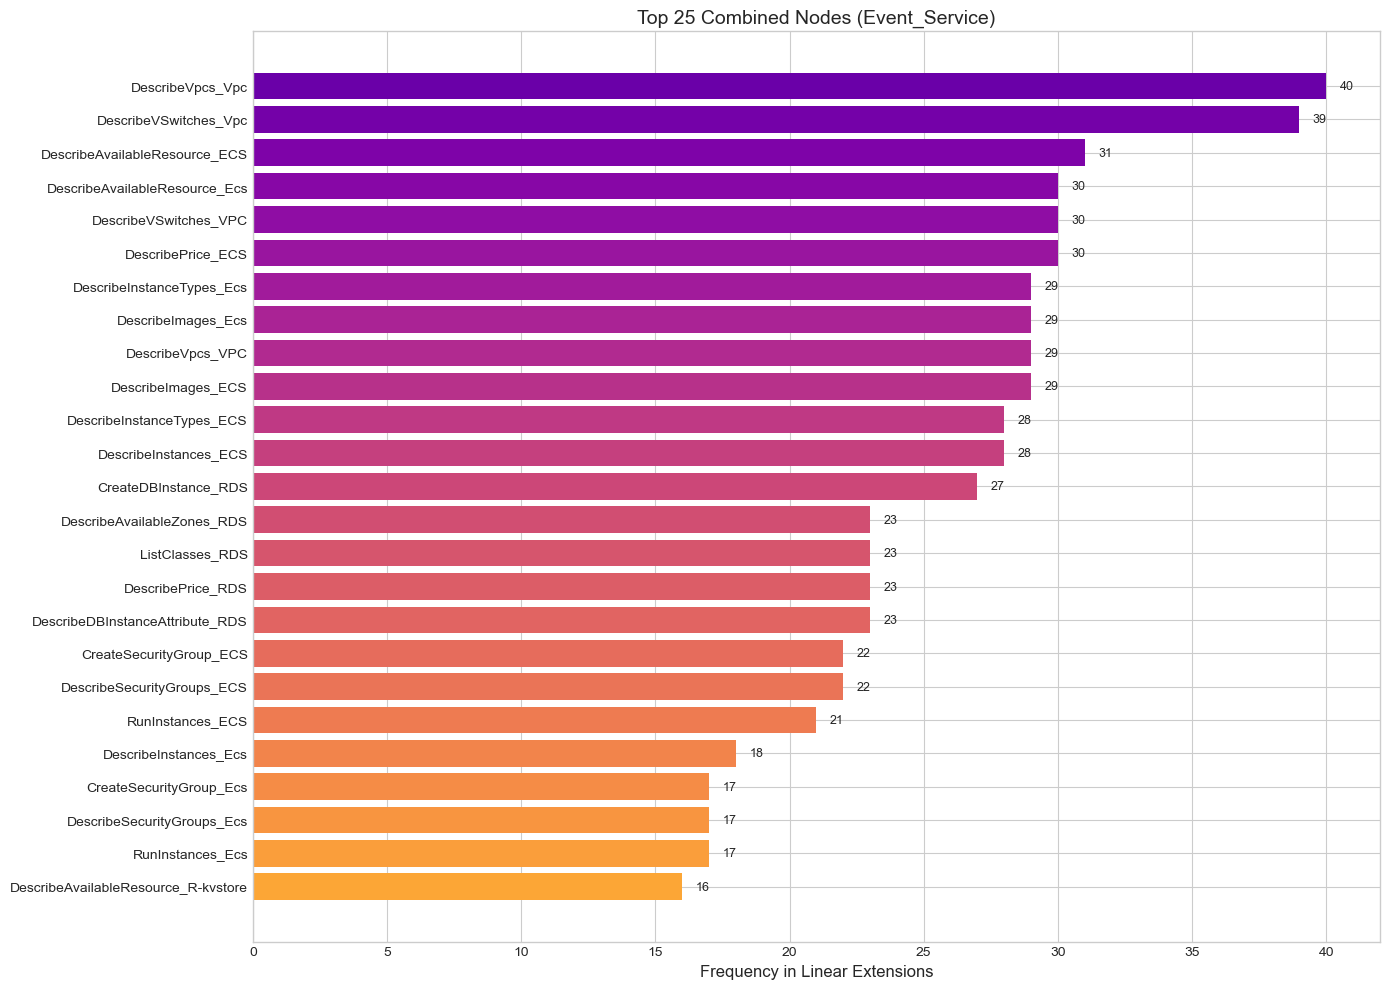

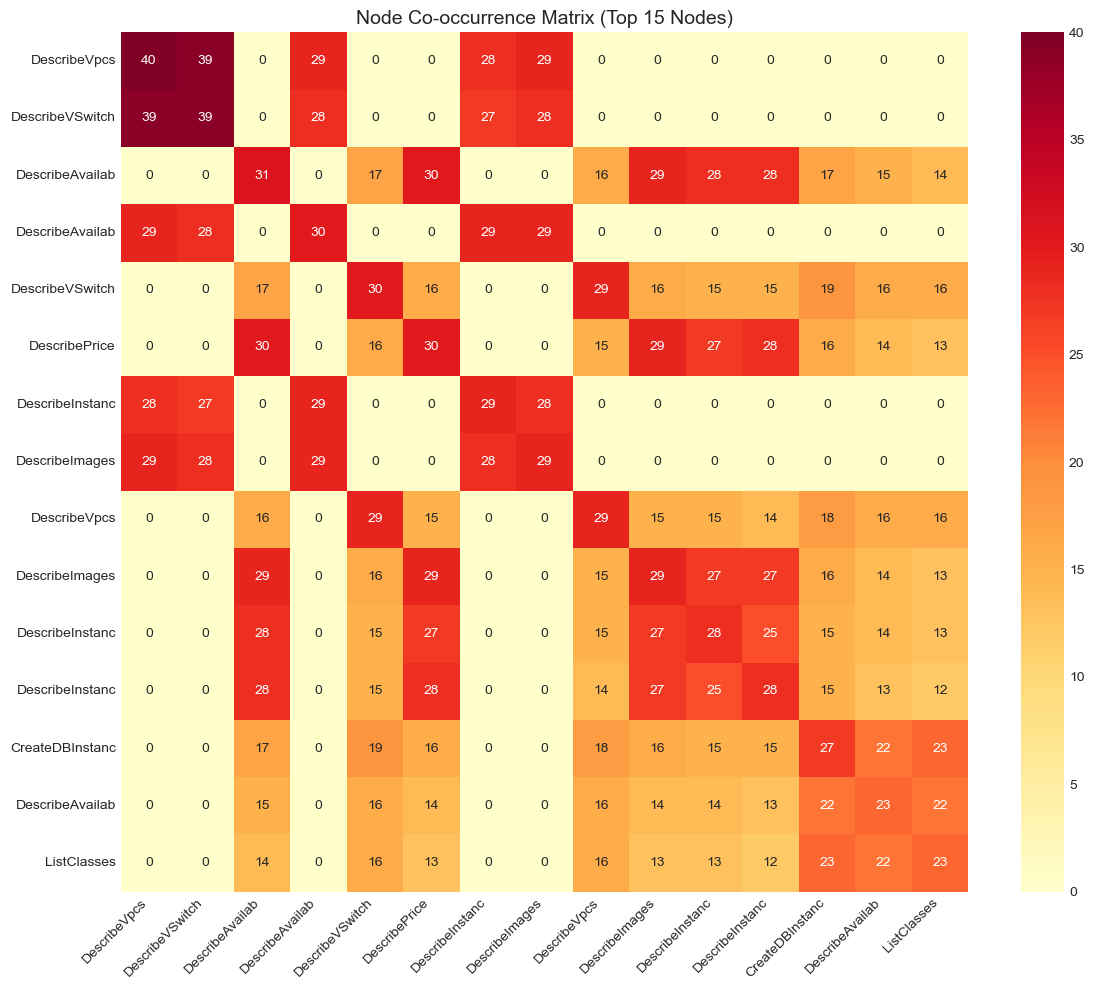

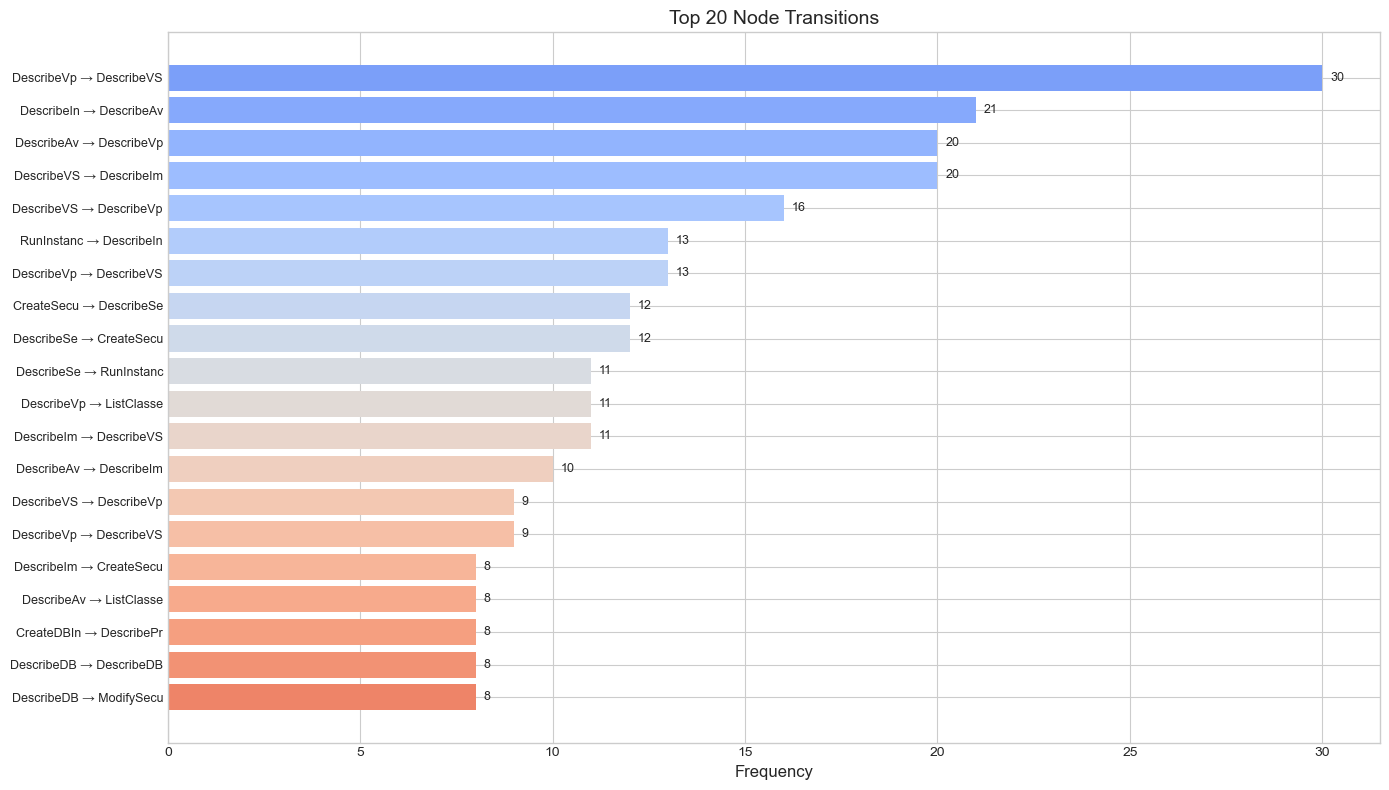

,Metric,Value
0,Total Events in Dataset,1672
1,Number of Sessions (Observations),91
2,Unique Combined Nodes,107
3,Unique Event Names,59
4,Unique Service Names,14
5,Min Sequence Length,1
6,Max Sequence Length,32
7,Mean Sequence Length,11.77
8,Median Sequence Length,10.00
9,Std Sequence Length,6.78


In [ ]:
print("Sample Linear Extensions (first 5 sessions):")
print("=" * 80)

for i, (session_id, sequence) in enumerate(list(linear_extensions.items())[:5]):
    print(f"\n📋 Session {i+1} (ID: {session_id[:30]}...)")
    print(f"   Length: {len(sequence)} nodes")
    print(f"   Sequence:")
    for j, node in enumerate(sequence):
        print(f"      {j+1:2d}. {node}")


Sample Linear Extensions (first 5 sessions):

📋 Session 1 (ID: 2025102009292712002f5730b14148...)
   Length: 6 nodes
   Sequence:
       1. DescribeAvailableZones_Rds
       2. ListClasses_Rds
       3. DescribeVpcs_Vpc
       4. DescribeVSwitches_Vpc
       5. CreateDBInstance_Rds
       6. DescribeDBInstanceAttribute_Rds

📋 Session 2 (ID: 20251020094133e13941b5fd084ea1...)
   Length: 6 nodes
   Sequence:
       1. DescribeAvailableZones_Rds
       2. ListClasses_Rds
       3. DescribeVpcs_Vpc
       4. DescribeVSwitches_Vpc
       5. CreateDBInstance_Rds
       6. DescribeDBInstanceAttribute_Rds

📋 Session 3 (ID: 202510200953342a7f2cb9bc034df6...)
   Length: 9 nodes
   Sequence:
       1. DescribeInstanceTypes_Ecs
       2. DescribeAvailableResource_Ecs
       3. DescribeVpcs_Vpc
       4. DescribeVSwitches_Vpc
       5. DescribeImages_Ecs
       6. CreateSecurityGroup_Ecs
       7. DescribeSecurityGroups_Ecs
       8. RunInstances_Ecs
       9. DescribeInstances_Ecs

📋 Session 4 (ID

✅ Processed data saved to: iac_cloud_processed_data.pkl

Data contains:
  - 91 rankings (as integer sequences)
  - 107 unique nodes with index mapping
  - Linear extensions as node name sequences
  - Session statistics DataFrame
